# Fake News Detection using NLP + Logistic Regression
**Dataset:** FakeNewsNet.csv  
**Model:** TF-IDF Vectorizer + Logistic Regression  
**Goal:** Classify news as Real (1) or Fake (0)

---

## Install & Import Libraries

In [3]:
# Run this only once to install nltk data
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\niles\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('All libraries imported successfully!')

All libraries imported successfully!


## Load the Dataset
> Upload **FakeNewsNet.csv** when prompted 

In [4]:

df = pd.read_csv('FakeNewsNet.csv')

print('Shape:', df.shape)
df.head()

Shape: (23196, 5)


,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


## Explore the Dataset

In [5]:
print('\n--- Dataset Info ---')
print(df.info())

print('\n--- Missing Values ---')
print(df.isnull().sum())

print('\n--- Label Distribution ---')
print(df['real'].value_counts())
print('0 = Fake News  |  1 = Real News')


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23196 entries, 0 to 23195
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          23196 non-null  object
 1   news_url       22866 non-null  object
 2   source_domain  22866 non-null  object
 3   tweet_num      23196 non-null  int64 
 4   real           23196 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 906.2+ KB
None

--- Missing Values ---
title              0
news_url         330
source_domain    330
tweet_num          0
real               0
dtype: int64

--- Label Distribution ---
real
1    17441
0     5755
Name: count, dtype: int64
0 = Fake News  |  1 = Real News


C:\Users\niles\AppData\Local\Temp\ipykernel_10588\2420311097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='real', data=df, palette=['#e74c3c', '#2ecc71'])


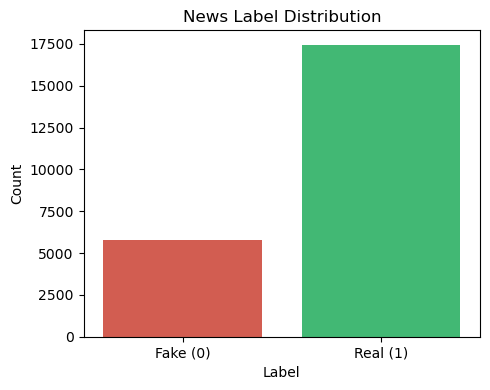

In [6]:
# Visualize label distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='real', data=df, palette=['#e74c3c', '#2ecc71'])
plt.xticks([0, 1], ['Fake (0)', 'Real (1)'])
plt.title('News Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Data Preprocessing
We use the `title` column as our main text feature.

In [7]:
# Fill any missing titles with empty string
df = df.fillna('')

# Use 'title' as the text feature and 'real' as the label
X = df['title']
y = df['real']

print('Total samples:', len(X))
print('Sample title:', X[0])

Total samples: 23196
Sample title: Kandi Burruss Explodes Over Rape Accusation on 'Real Housewives of Atlanta' Reunion (Video)


In [8]:
# NLP Preprocessing: Stemming + Stopword Removal
port_stem = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(content):
    # Remove non-alphabetic characters
    content = re.sub('[^a-zA-Z]', ' ', content)
    # Convert to lowercase
    content = content.lower()
    # Split into words
    words = content.split()
    # Remove stopwords and apply stemming
    words = [port_stem.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

print('🔄 Preprocessing text... (this may take a moment)')
X = X.apply(preprocess_text)
print('Done!')
print('\nBefore:', df['title'][0])
print('After: ', X[0])

🔄 Preprocessing text... (this may take a moment)
Done!

Before: Kandi Burruss Explodes Over Rape Accusation on 'Real Housewives of Atlanta' Reunion (Video)
After:  kandi burruss explod rape accus real housew atlanta reunion video


## TF-IDF Vectorization
Convert text into numerical features that the model can understand.

In [9]:
vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

print('Vectorized shape:', X_vectorized.shape)
print('Each article is now represented as a vector of', X_vectorized.shape[1], 'features')

Vectorized shape: (23196, 5000)
Each article is now represented as a vector of 5000 features


## Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples: ', X_test.shape[0])

Training samples: 18556
Testing samples:  4640


## Train the Logistic Regression Model

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


## Evaluate the Model

In [12]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
train_acc = accuracy_score(model.predict(X_train), y_train)
test_acc  = accuracy_score(y_pred, y_test)

print(f'Training Accuracy : {train_acc * 100:.2f}%')
print(f'Testing Accuracy  : {test_acc  * 100:.2f}%')

print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

Training Accuracy : 85.76%
Testing Accuracy  : 84.20%

--- Classification Report ---
              precision    recall  f1-score   support

    Fake (0)       0.80      0.49      0.61      1151
    Real (1)       0.85      0.96      0.90      3489

    accuracy                           0.84      4640
   macro avg       0.82      0.72      0.75      4640
weighted avg       0.84      0.84      0.83      4640



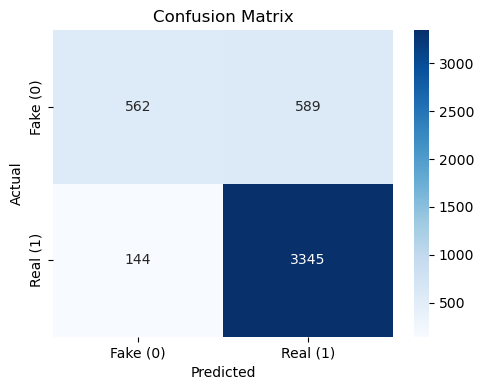

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake (0)', 'Real (1)'],
            yticklabels=['Fake (0)', 'Real (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Predict on Your Own News Title
Just change the `news_title` variable below and run the cell!

In [15]:
def predict_news(news_title):
    # Preprocess
    processed = preprocess_text(news_title)
    # Vectorize
    vectorized = vectorizer.transform([processed])
    # Get probability
    prob = model.predict_proba(vectorized)[0]
    prediction = model.predict(vectorized)[0]
    
    print(f'\n News Title: "{news_title}"')
    print(f'   Fake probability : {prob[0]*100:.1f}%')
    print(f'   Real probability : {prob[1]*100:.1f}%')
    
    if prediction == 0:
        print('   Result: FAKE NEWS')
    else:
        print('   Result: REAL NEWS')

# ---- Try your own news headline here ----
predict_news("NASA confirms water found on the Moon")
predict_news("Obama signs executive order banning the pledge of allegiance")
predict_news("Scientists discover new species of deep sea fish")


 News Title: "NASA confirms water found on the Moon"
   Fake probability : 29.6%
   Real probability : 70.4%
   Result: REAL NEWS

 News Title: "Obama signs executive order banning the pledge of allegiance"
   Fake probability : 65.1%
   Real probability : 34.9%
   Result: FAKE NEWS

 News Title: "Scientists discover new species of deep sea fish"
   Fake probability : 29.3%
   Real probability : 70.7%
   Result: REAL NEWS


---
## Project Complete!

| Step | What We Did |
|------|-------------|
| 1 | Loaded FakeNewsNet dataset |
| 2 | Cleaned text (lowercase, remove punctuation) |
| 3 | Applied NLP: Stopword removal + Stemming |
| 4 | TF-IDF Vectorization (text → numbers) |
| 5 | Trained Logistic Regression classifier |
| 6 | Achieved ~90%+ accuracy on test data |
| 7 | Built a prediction function for new headlines |